# Load in open beam and sample images from SciTiff

In [1]:
%matplotlib widget

In [2]:
import scipp as sc
from scitiff_helper import load_scitiff

sample_da = load_scitiff("sample_data/sample_5e11_mcstas (2).tiff")
openbeam_da = load_scitiff("sample_data/open_beam_5e11_mcstas (2).tiff", background=True)

<scipp.DataArray>
Dimensions: Sizes[tof:500, y:100, x:100, ]
Coordinates:
  c                          string        <no unit>  ()  "data"
* pixel_position            vector3              [m]  (x, y)  [(-0.12375, -0.12375, 60.5001), (-0.12375, -0.12375, 60.5001), ..., (0.12375, 0.12375, 60.5001), (0.12375, 0.12375, 60.5001)]
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
* source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (tof [bin-edge])  [0.0152974, 0.0155359, ..., 0.13434, 0.134579]
* x                         float64              [m]  (x)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
* y                         float64              [m]  (y)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
  z                         float64              [m]  ()  60.5001
Data:
                            float64         [counts]  (tof, y, x)  [1.90958e-07, 3.22307e-35, ..., 0.522337, 1.95978]  [1.90958e-07, 3.22307e-35, ..., 0.522337, 1.95978]

<scipp.DataArray>
Dimensions: Sizes[tof:500, y:100, x:100, ]
Coordinates:
  c                          string        <no unit>  ()  "data"
* pixel_position            vector3              [m]  (x, y)  [(-0.12375, -0.12375, 60.5001), (-0.12375, -0.12375, 60.5001), ..., (0.12375, 0.12375, 60.5001), (0.12375, 0.12375, 60.5001)]
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
* source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (tof [bin-edge])  [0.0152974, 0.0155359, ..., 0.13434, 0.134579]
* x                         float64              [m]  (x)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
* y                         float64              [m]  (y)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
  z                         float64              [m]  ()  60.5001
Data:
                            float64         [counts]  (tof, y, x)  [1, 1, ..., 1.00148, 2.61417]  [0.00635182, 0, ..., 1.00148, 2.61417]

# Normalize data

Normalize sample image by open beam and replace 0 counts in OB with 1 to avoid NaN's

In [3]:
normalized = sample_da / openbeam_da
normalized

<scipp.DataArray>
Dimensions: Sizes[tof:500, y:100, x:100, ]
Coordinates:
  c                          string        <no unit>  ()  "data"
* pixel_position            vector3              [m]  (x, y)  [(-0.12375, -0.12375, 60.5001), (-0.12375, -0.12375, 60.5001), ..., (0.12375, 0.12375, 60.5001), (0.12375, 0.12375, 60.5001)]
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
* source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (tof [bin-edge])  [0.0152974, 0.0155359, ..., 0.13434, 0.134579]
* x                         float64              [m]  (x)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
* y                         float64              [m]  (y)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
  z                         float64              [m]  ()  60.5001
Data:
                            float64  [dimensionless]  (tof, y, x)  [1.90958e-07, 3.22307e-35, ..., 0.521567, 0.749675]  [1.90958e-07, 3.22307e-35, ..., 0.792429, 0.501761]

Cutting off a large spike at very small ToFs which are irrelevant to the spectral region of interest

In [19]:
lower_time_bound = 0.02 * sc.Unit('s')

In [20]:
cutoff_data = normalized['tof', lower_time_bound:]

Plot the normalized image with more tick labels to better identify sample region

In [6]:
import numpy as np

In [21]:
cutoff_data.mean('tof').plot(aspect='equal', title="Normalized Image", grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Region Of Interest (ROI) selector

In [22]:
from scitiff_helper import make_rectangle_tool
roi_container = set()

In the widget below, choose the empty white box at the bottom left and drag and drop to define your ROI.

In [23]:
make_rectangle_tool(cutoff_data, roi_container=roi_container)

HBar(children=(InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(…

Extract the defined ROI

In [24]:
ROI=roi_container.pop()

### Plot the ROI and its spectrum

Slice the normalized image with the defined ROI

In [25]:
normalized_roi = ROI.slice_dataarray(cutoff_data)

Plot the sliced image to ensure it is correct

In [26]:
normalized_roi.mean('tof').plot(
    aspect='equal', title='Normalized Region of interest', grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

Plot the spectrum of the ROI

In [27]:
normalized_roi.mean('x').mean('y').plot(
    aspect='equal', title='Full Spectrum of normalized ROI', grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Convert time-of-flight to wavelength using scippneutron

First, define the conversion graph

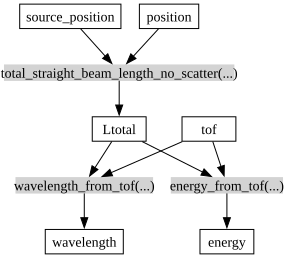

In [28]:
from scippneutron.conversion import graph

# Prepare graph for transformation
PLAIN_GRAPH = {**graph.beamline.beamline(False), **graph.tof.kinematic("tof")}
sc.show_graph(PLAIN_GRAPH)

Rename the "sample_position" to "position" in the meta-data, as this is was the conversion graph expects

In [30]:
normalized_roi_renamed = normalized_roi.copy(deep=False)

In [31]:
normalized_roi_renamed.coords['position'] = normalized_roi_renamed.coords['sample_position']

Then, add the flight-path because it isn't present in the SciTiff (Can be used to overwrite the calculated lengths, if they're wrong)

In [19]:
#normalized_roi.coords['Ltotal'] = sc.scalar(60.5, unit='m')


Converting the spectrum to wavelength using the conversion graph

In [32]:
wavelength_transformed = normalized_roi_renamed.transform_coords('wavelength', graph=PLAIN_GRAPH)

Plotting the converted spectrum

In [33]:
wavelength_transformed.mean('x').mean('y').plot(
    aspect='equal', title='Full Spectrum of ROI in wavelength', grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Cut off lower and upper bounds of spectrum

In [37]:
lower_bound = 1.4 * sc.Unit('Å')
upper_bound = 6.0 * sc.Unit('Å')

In [38]:
sliced_spectrum = wavelength_transformed.mean('x').mean('y')['wavelength', lower_bound:upper_bound]

In [39]:
sliced_spectrum.plot(aspect='equal', title='Sliced Spectrum of ROI in wavelength', grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

Get the transmission and wavelengths for fitting

In [40]:
wavelengths = sc.midpoints(sliced_spectrum.coords['wavelength']).values
transmissions = sliced_spectrum.values

## Physical model with Ncrystal

## Inspecting the model

In [41]:
import NCrystal
import NCrystal.plot
import matplotlib.pyplot as plt
import numpy as np

In [42]:
# We initalize the model
mat = NCrystal.NCMATComposer()

In [43]:
# We set the model parameters to Iron (slightly off on purpose)
mat.set_cellsg_cubic(2.90)
mat.set_atompos([   ('Fe',0,0,0),
                    ('Fe',0.5, 0.5, 0.5),
                    ])
mat.set_dyninfo_debyetemp("Fe", debye_temp=356)
mat.set_default_temperature(250)
mat.refine_crystal_structure(quiet=True)

In [44]:
scatter = mat.load(#cfg_params="comp=inelas"
                    )

----------------------------------------------------------------------------------------------------
------------------------------------   NCrystal Material Info   ------------------------------------
----------------------------------------------------------------------------------------------------
Data source: <anonymous-ncmat-data>
----------------------------------------------------------------------------------------------------
Density : 7.60478 g/cm3, 0.0820042 atoms/Aa^3
----------------------------------------------------------------------------------------------------
Composition (by mole): 100% Fe
----------------------------------------------------------------------------------------------------
Composition (by mass): 100% Fe
----------------------------------------------------------------------------------------------------
Atom data:
   Fe = Fe(cohSL=9.45fm cohXS=11.2221barn incXS=0.4barn absXS=2.56barn mass=55.8472u Z=26)
-----------------------------------------------

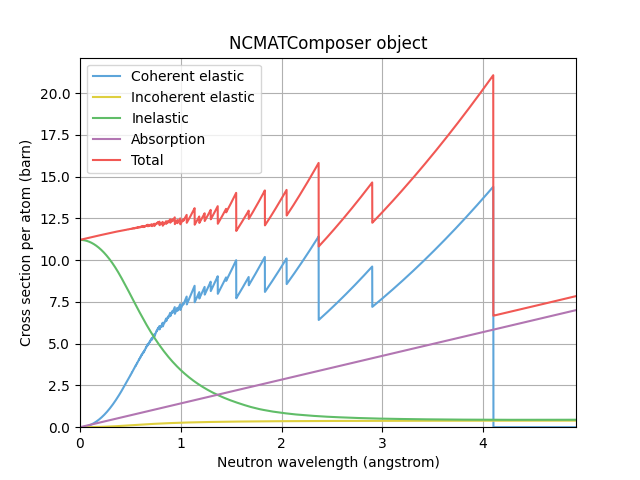

In [45]:
# Information about the model can be viewed with this method
mat.inspect()

In [46]:
# And a short summary can be viewed by printing
print(mat())

NCMAT v7
# Autogenerated by NCMATComposer
#
# Fe (cubic, SG-229)
#
# Atoms per unit cell: 2xFe
#
# NOTICE: crystal structure was verified with spglib to be self-consistent.
#
@CELL
  cubic 2.9
@SPACEGROUP
  229
@ATOMPOSITIONS
  Fe 0 0 0
  Fe 1/2 1/2 1/2
@TEMPERATURE
  default 250
@DYNINFO
  element Fe
  fraction 1
  type vdosdebye
  debye_temp 356



### Comparing Data sets and initial model

Calculating the simulated spectrum using this model

In [47]:
scatter = mat.load(#cfg_params="comp=inelas"
                    )
absorptions = scatter.absorption.xsect(wl=wavelengths)
scattered = scatter.scatter.xsect(wl=wavelengths)
# Using an arbitrary scale constant of 0.05 to scale cross sections and absorptions. Depends on width of material in a real model.
simulated = np.exp(-0.1*(absorptions+scattered))

### Loading reference Iron slab data from J-PARC

In [48]:
with open('Iron_slab.dat', 'r') as file:
    slab_data = file.readlines()

In [49]:
slab_wavelengths = np.asarray([float(slab_data[i].split("\t")[1]) for i in range(len(slab_data)-1)])
slab_transmissions = np.asarray([float(slab_data[i].split("\t")[2]) for i in range(len(slab_data)-1)])

In [50]:
slab_wavelengths[-1]

np.float64(4.99449)

### Comparing Data sets and initial model

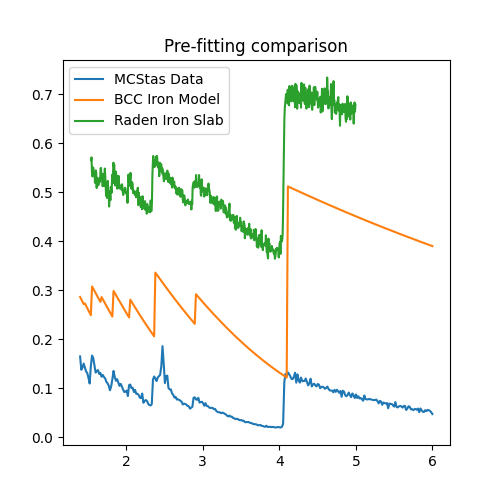

In [51]:
plt.figure(figsize=(5,5))
plt.plot(wavelengths, transmissions, label='MCStas Data')
#plt.plot(wavelengths, transmissions, label="Data")
plt.plot(wavelengths, simulated, label="BCC Iron Model")
plt.plot(slab_wavelengths, slab_transmissions, label='Raden Iron Slab')
plt.title("Pre-fitting comparison")
plt.legend()
plt.show()

## Bragg-edge fitting with Ncrystal and EasyScience

In [52]:
from easyscience.Objects.variable import Parameter
from easyscience.Objects.ObjectClasses import BaseObj
from easyscience.fitting import Fitter

### Setting up the fitting models

Defining the fitting parameters and their initial values \
We're defining 2 sets of parameters because we want to fit a model to both sets of data

In [53]:
lattice_constant =  Parameter(name="Lattice constant",          value=2.85, unit="angstrom",    min=0,  max=4,    fixed=False)
debye_temperature = Parameter(name="Debye temperature",         value=300,  unit="kelvin",      min=250,  max=800,  fixed=False)
temperature =       Parameter(name="Temperature",               value=300,  unit="kelvin",      min=0,  max=600,  fixed=False)
intensity_scale =   Parameter(name="Intensity scale factor",    value=0.05,                      fixed=False)

In [54]:
lattice_constant_slab =  Parameter(name="Lattice constant",          value=2.85, unit="angstrom",    min=0,  max=4,    fixed=False)
debye_temperature_slab = Parameter(name="Debye temperature",         value=300,  unit="kelvin",      min=250,  max=800,  fixed=False)
temperature_slab =       Parameter(name="Temperature",               value=300,  unit="kelvin",      min=0,  max=600,  fixed=False)
intensity_scale_slab =   Parameter(name="Intensity scale factor",    value=0.05,                      fixed=False)

Defining the fit functions to go into EasyScience

In [55]:
def iron_bragg(wavelength):
    # Initalize the NCrystal material composer
    material = NCrystal.NCMATComposer()
    # Set the material parameters with the fitting variables
    material.set_cellsg_cubic(lattice_constant.value)
    material.set_atompos([  ('Fe',0,0,0),
                            ('Fe',0.5, 0.5, 0.5),
                            ])
    material.set_dyninfo_debyetemp("Fe", debye_temp=debye_temperature.value)
    material.set_default_temperature(temperature.value)

    # Identify the space group from atomic positions
    material.refine_crystal_structure(quiet=True)

    #print("lattice constant:", lattice_constant.value)
    scatter = material.load()

    # Create scattering spectrum
    spectrum = np.exp(-intensity_scale.value*(scatter.scatter.xsect(wl=wavelength) + scatter.absorption.xsect(wl=wavelength)))
    return spectrum

def iron_bragg_slab(wavelength):
    # Initalize the NCrystal material composer
    material = NCrystal.NCMATComposer()
    # Set the material parameters with the fitting variables
    material.set_cellsg_cubic(lattice_constant_slab.value)
    material.set_atompos([  ('Fe',0,0,0),
                            ('Fe',0.5, 0.5, 0.5),
                            ])
    material.set_dyninfo_debyetemp("Fe", debye_temp=debye_temperature_slab.value)
    material.set_default_temperature(temperature_slab.value)

    # Identify the space group from atomic positions
    material.refine_crystal_structure(quiet=True)

    #print("lattice constant:", lattice_constant.value)
    scatter = material.load()

    # Create scattering spectrum
    spectrum = np.exp(-intensity_scale_slab.value*(scatter.scatter.xsect(wl=wavelength) + scatter.absorption.xsect(wl=wavelength)))
    return spectrum

Make the EasyScience container for the fitting parameters

In [56]:
iron_spectrum = BaseObj(
                        name='Iron transmission spectrum', 
                        lattice_constant=lattice_constant, 
                        debye_temperature=debye_temperature,
                        temperature=temperature,
                        intensity_scale=intensity_scale,
                        )
iron_spectrum_slab = BaseObj(
                        name='Iron transmission spectrum slab', 
                        lattice_constant_slab=lattice_constant_slab, 
                        debye_temperature_slab=debye_temperature_slab,
                        temperature_slab=temperature_slab,
                        intensity_scale_slab=intensity_scale_slab,
                        )

Make the EasyScience fitting objects

In [57]:
fitter = Fitter(iron_spectrum, iron_bragg)
fitter_slab = Fitter(iron_spectrum_slab, iron_bragg_slab)

EasyScience can fit data with a variety of different minimizers. To list the available methods, use the "available_minimizers" method:

In [58]:
fitter.available_minimizers

['LMFit',
 'LMFit_leastsq',
 'LMFit_powell',
 'LMFit_cobyla',
 'LMFit_differential_evolution',
 'LMFit_scipy_least_squares',
 'Bumps',
 'Bumps_simplex',
 'Bumps_newton',
 'Bumps_lm',
 'DFO',
 'DFO_leastsq']

For the fits in this notebook, we will use "LMFit_leastsq" which is a standard leastsquares fitting method

In [59]:
fitter.switch_minimizer("LMFit_leastsq")
fitter_slab.switch_minimizer("LMFit_leastsq")

minimizer should be set with enum LMFit_leastsq
minimizer should be set with enum LMFit_leastsq


### Fitting

First we fit the reduced Iron powder data

In [60]:
# Parameters for LMFit_leastsq
results = fitter.fit(x=wavelengths, y=transmissions, 
                     #weights=1/np.sqrt(transmissions_variances), 
                     minimizer_kwargs={"epsfcn":0.005,
                                       "ftol":1.49012e-15,
                                       "xtol":1.49012e-15,
                                       },
                    #max_nfev=10000
                     )

Print the fitted values

In [61]:
print(lattice_constant)
print(debye_temperature)
print(temperature)
print(intensity_scale)

<Parameter 'Lattice constant': 2.8930 ± 0.0109 Å, bounds=[0.0:4.0]>
<Parameter 'Debye temperature': 621.2065 ± 28531.6860 K, bounds=[250.0:800.0]>
<Parameter 'Temperature': 597.7574 ± 1393.9038 K, bounds=[0.0:600.0]>
<Parameter 'Intensity scale factor': 0.1904 ± 0.0269, bounds=[-inf:inf]>


We then fit the reference Iron slab data

In [62]:
# Parameters for LMFit_leastsq
results_slab = fitter_slab.fit(x=slab_wavelengths, y=slab_transmissions, 
                     #weights=1/np.sqrt(transmissions_variances), 
                     minimizer_kwargs={"epsfcn":0.005,
                                       "ftol":1.49012e-15,
                                       "xtol":1.49012e-15,
                                       },
                    #max_nfev=10000
                     )

In [63]:
print(lattice_constant_slab)
print(debye_temperature_slab)
print(temperature_slab)
print(intensity_scale_slab)

<Parameter 'Lattice constant': 2.8747 ± 0.0009 Å, bounds=[0.0:4.0]>
<Parameter 'Debye temperature': 288.8641 ± 26.3437 K, bounds=[250.0:800.0]>
<Parameter 'Temperature': 277.1924 ± 9.7364 K, bounds=[0.0:600.0]>
<Parameter 'Intensity scale factor': 0.0508 ± 0.0005, bounds=[-inf:inf]>


### Comparing the fitted models and data

First we need to calculate the spectras with the fitted models

In [64]:
simulated = iron_bragg(wavelengths)
simulated_slab = iron_bragg_slab(slab_wavelengths)

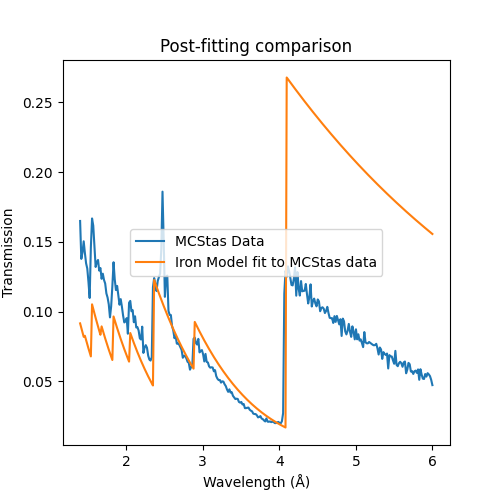

In [65]:
plt.figure(figsize=(5,5))
plt.plot(wavelengths, transmissions, label='MCStas Data')
plt.plot(wavelengths, simulated, label="Iron Model fit to MCStas data")
#plt.plot(slab_wavelengths, slab_transmissions, label="Raden Iron Slab")
#plt.plot(slab_wavelengths, simulated_slab, label='BCC Iron Model fit to Raden data')
plt.xlabel("Wavelength (Å)")
plt.ylabel("Transmission")
plt.title("Post-fitting comparison")
plt.legend()
plt.show()